In [2]:
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [3]:
with open('training_results/training_regression_mse_losses_05_05.txt', 'r') as f:
    rrr_mse_losses = json.loads(f.read())

with open('training_results/training_regression_nmse_losses_05_05.txt', 'r') as f:
    rrr_nmse_losses = json.loads(f.read())


rrr_configs = np.array(list(rrr_mse_losses.keys()))
rrr_mse_losses_array = np.array([list(losses.values()) for losses in rrr_mse_losses.values()])
rrr_nmse_losses_array = np.array([list(losses.values()) for losses in rrr_nmse_losses.values()])

rrr_mean_mse_loss = np.mean(rrr_mse_losses_array, axis=1)
rrr_mean_nmse_loss = np.mean(rrr_nmse_losses_array, axis=1)

rrr_best_mean_mse_indices = np.argsort(rrr_mean_mse_loss)[:5]
rrr_best_mean_mse_models = rrr_configs[rrr_best_mean_mse_indices]
rrr_best_mean_mse_losses = rrr_mean_mse_loss[rrr_best_mean_mse_indices]

rrr_best_mean_nmse_indices = np.argsort(rrr_mean_nmse_loss)[:5]
rrr_best_mean_nmse_models = rrr_configs[rrr_best_mean_nmse_indices]
rrr_best_mean_nmse_losses = rrr_mean_nmse_loss[rrr_best_mean_nmse_indices]

In [4]:
with open('training_results/training_vae_mse_losses_06_06_2025.txt', 'r') as f:
    vae_mse_losses = json.loads(f.read())

with open('training_results/training_vae_nmse_losses_06_06_2025.txt', 'r') as f:
    vae_nmse_losses = json.loads(f.read())


vae_configs = np.array(list(vae_mse_losses.keys()))
vae_mse_losses_array = np.array([list(losses.values()) for losses in vae_mse_losses.values()])
vae_nmse_losses_array = np.array([list(losses.values()) for losses in vae_nmse_losses.values()])

vae_mean_mse_loss = np.mean(vae_mse_losses_array, axis=1)
vae_mean_nmse_loss = np.mean(vae_nmse_losses_array, axis=1)

vae_best_mean_mse_indices = np.argsort(vae_mean_mse_loss)[:5]
vae_best_mean_mse_models = vae_configs[vae_best_mean_mse_indices]
vae_best_mean_mse_losses = vae_mean_mse_loss[vae_best_mean_mse_indices]

vae_best_mean_nmse_indices = np.argsort(vae_mean_nmse_loss)[:5]
vae_best_mean_nmse_models = vae_configs[vae_best_mean_nmse_indices]
vae_best_mean_nmse_losses = vae_mean_nmse_loss[vae_best_mean_nmse_indices]

In [5]:
with open('training_results/training_cvae_mse_losses_06_06_2025.txt', 'r') as f:
    cvae_mse_losses = json.loads(f.read())

with open('training_results/training_cvae_nmse_losses_06_06_2025.txt', 'r') as f:
    cvae_nmse_losses = json.loads(f.read())


cvae_configs = np.array(list(cvae_mse_losses.keys()))
cvae_mse_losses_array = np.array([list(losses.values()) for losses in cvae_mse_losses.values()])
cvae_nmse_losses_array = np.array([list(losses.values()) for losses in cvae_nmse_losses.values()])

cvae_mean_mse_loss = np.mean(cvae_mse_losses_array, axis=1)
cvae_mean_nmse_loss = np.mean(cvae_nmse_losses_array, axis=1)

cvae_best_mean_mse_indices = np.argsort(cvae_mean_mse_loss)[:5]
cvae_best_mean_mse_models = cvae_configs[cvae_best_mean_mse_indices]
cvae_best_mean_mse_losses = cvae_mean_mse_loss[cvae_best_mean_mse_indices]

cvae_best_mean_nmse_indices = np.argsort(cvae_mean_nmse_loss)[:5]
cvae_best_mean_nmse_models = cvae_configs[cvae_best_mean_nmse_indices]
cvae_best_mean_nmse_losses = cvae_mean_nmse_loss[cvae_best_mean_nmse_indices]

In [17]:
rrr_mse_model, rr_mse_loss = rrr_best_mean_mse_models[0], rrr_best_mean_mse_losses[0]
vae_mse_model, vae_mse_loss = vae_best_mean_mse_models[0], vae_best_mean_mse_losses[0]
cvae_mse_model, cvae_mse_loss = cvae_best_mean_mse_models[0], cvae_best_mean_mse_losses[0]

top_mse_data = {'models': [rrr_mse_model, vae_mse_model, cvae_mse_model],
            'losses': [rr_mse_loss, vae_mse_loss, cvae_mse_loss]}

rrr_nmse_model, rr_nmse_loss = rrr_best_mean_nmse_models[0], rrr_best_mean_nmse_losses[0]
vae_nmse_model, vae_nmse_loss = vae_best_mean_nmse_models[0], vae_best_mean_nmse_losses[0]
cvae_nmse_model, cvae_nmse_loss = cvae_best_mean_nmse_models[0], cvae_best_mean_nmse_losses[0]

top_nmse_data = {'models': [rrr_nmse_model, vae_nmse_model, cvae_nmse_model],
                 'losses': [rr_nmse_loss, vae_nmse_loss, cvae_nmse_loss]}

Text(0.5, 1.0, 'Best models according to MSE')

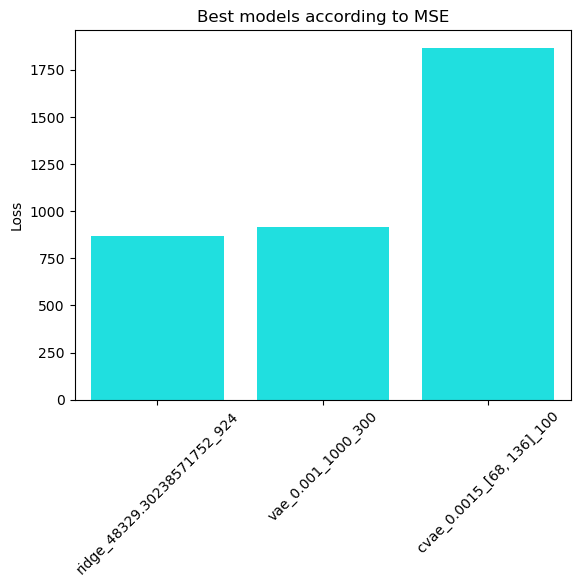

In [22]:
sns.barplot(x=top_mse_data['models'], y=top_mse_data['losses'], color='cyan')
plt.xticks(rotation=45)
plt.ylabel('Loss')
plt.title('Best models according to MSE')

Text(0.5, 1.0, 'Best models according to NMSE')

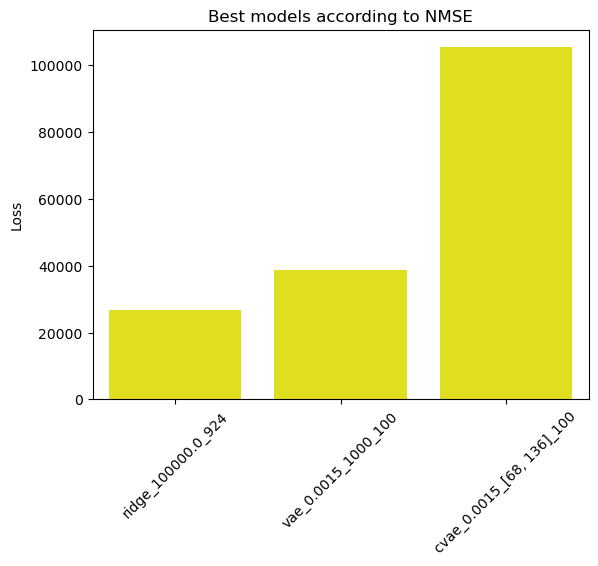

In [23]:
sns.barplot(x=top_nmse_data['models'], y=top_nmse_data['losses'], color='yellow')
plt.xticks(rotation=45)
plt.ylabel('Loss')
plt.title('Best models according to NMSE')